In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
#!pip install scikit-learn
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm

# Classification models used
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:\Users\thato\Downloads\Breast_Cancer.csv")
data.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [4]:
data.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [5]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


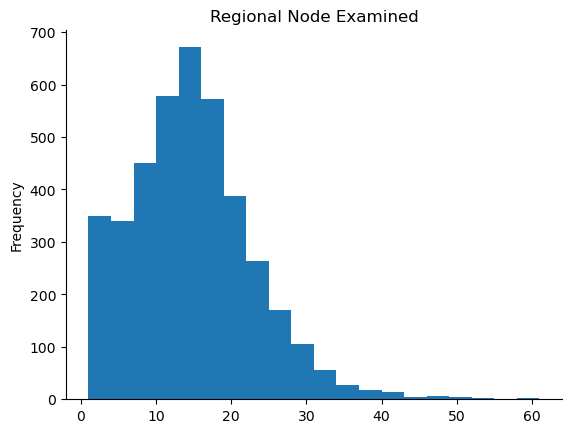

In [6]:
data['Regional Node Examined'].plot(kind='hist', bins=20, title='Regional Node Examined')
plt.gca().spines[['top', 'right',]].set_visible(False)

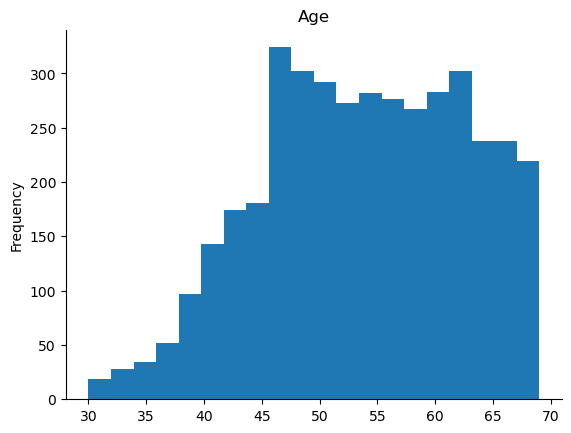

In [7]:
data['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

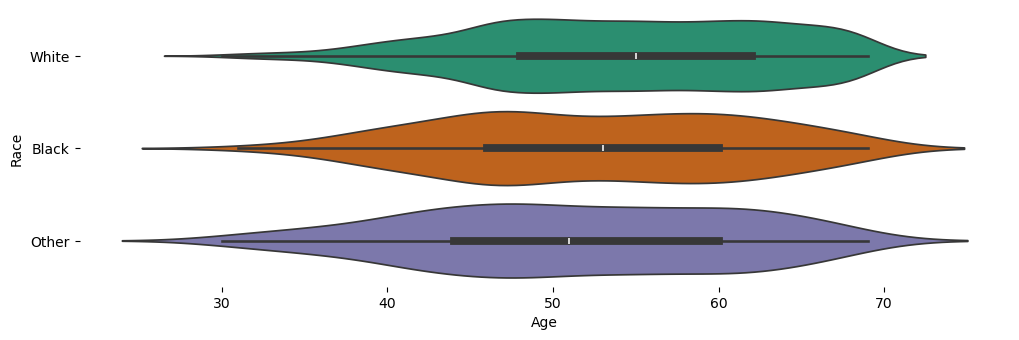

In [8]:
figsize = (12, 1.2 * len(data['Race'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data, x='Age', y='Race', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

# Encoding the Data
We apply *LabelEncoder()* to the columns that have object type to convert them to numerical values

In [9]:
encoder = LabelEncoder()
for col in data.select_dtypes("object"):
    data[col] =encoder.fit_transform(data[[col]])
data.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0


# Correlation
Our goal is to build models that predict the "Status" of a patient. To gain insight into how each predictor is likely to affect the patient's status, we examine the correlation between "Status" and the predictors, ranking them from highest to lowest correlation.

<Axes: >

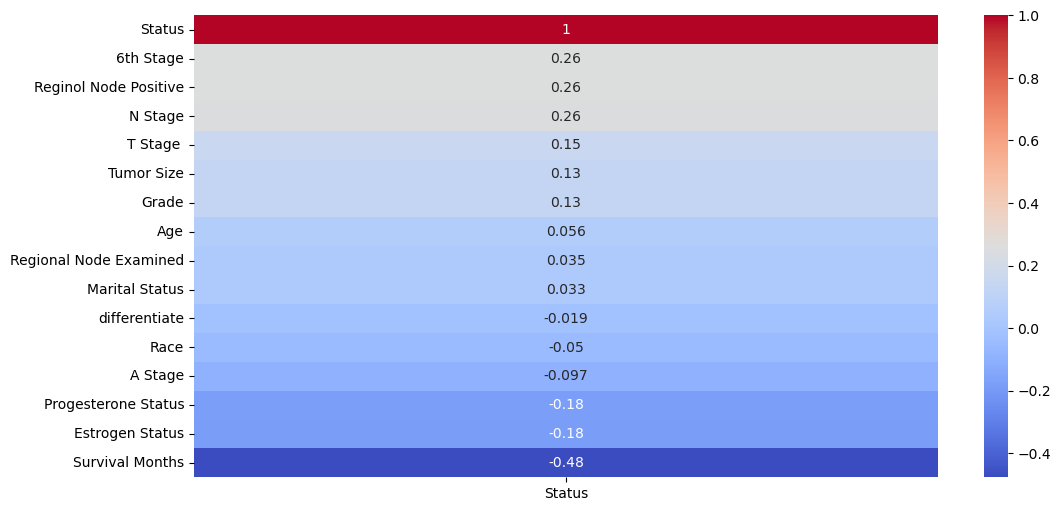

In [10]:
plt.figure(figsize=(12,6))
corr_matrix = data.corr()
status_corr=corr_matrix["Status"].sort_values(ascending=False)
sns.heatmap(status_corr.to_frame(), annot=True, cmap='coolwarm')

# Seperating and Scaling Data
We now seperate the features and target. Then we apply *StandardScaler()* to the feature dataframe to scale the data which can help improve model accuracy later on.

In [11]:
X = data.drop(columns="Status")
y = data.loc[:,"Status"]

scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 ,shuffle=True, random_state= 149)
X.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months
0,1.565253,0.39716,-0.349103,-1.025287,-0.632209,-1.043706,0.304678,1.351806,0.152963,-1.253661,0.267652,0.458107,1.190676,-0.618172,-0.492961
1,-0.443222,0.39716,-0.349103,0.281158,0.809974,0.535491,-0.679291,-0.205054,0.152963,0.214345,0.267652,0.458107,-0.044095,0.164807,-0.405695
2,0.449434,0.39716,-1.289389,1.587604,2.252157,2.114687,-0.679291,-0.205054,0.152963,1.540287,0.267652,0.458107,-0.044095,0.556296,0.161530
3,0.449434,0.39716,-0.349103,-1.025287,-0.632209,-1.043706,0.304678,1.351806,0.152963,-0.590691,0.267652,0.458107,-1.525820,-0.618172,0.554224
4,-0.777968,0.39716,-0.349103,0.281158,-0.632209,-0.254108,0.304678,1.351806,0.152963,0.498475,0.267652,0.458107,-1.402343,-0.618172,-0.929288


# Pre-Optimized Model Scores
Before optimizing any of the model parameters, we first evaluate the performance of the classification models without any adjustments or tuning. We do this by creating a dictionary of commonly used classification models and training each one on the training data. Each model is then ranked based on its accuracy score with the test data.

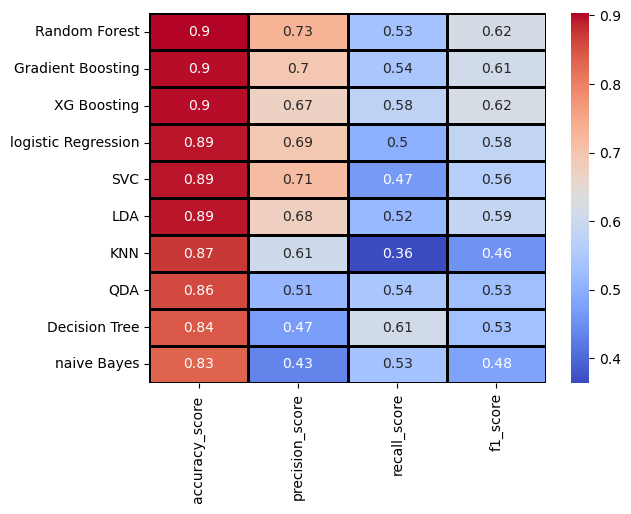

In [12]:
model_dic={
    'logistic Regression':LogisticRegression(),
    "Decision Tree":DTC(criterion='entropy'),
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

# Adjusting *k* parameter in K-Nearest-Neighboors
For KNN we can tune the model by calculating its cross-validated accuracy for different values of *k* from 1-30.

The optimal number of neighbors is 9 with an average training accuracy of 0.8739


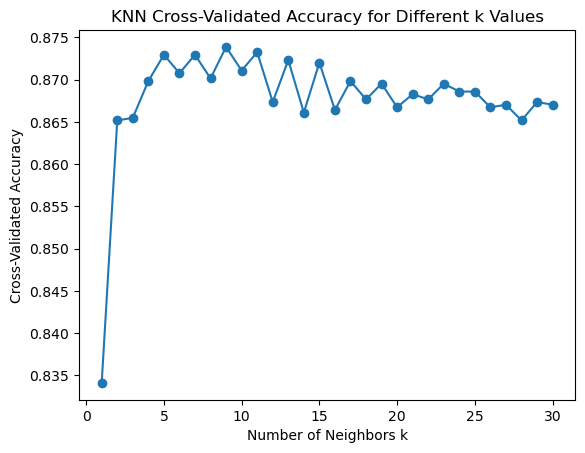

In [13]:
k_values = range(1, 31)
cv_scores = []

# Performing 10-fold cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Finding the optimal k with the highest CV accuracy
optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of neighbors is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Cross-Validated Accuracy for Different k Values')
plt.show()

# Optimizing *n* parameter for Random Forest Classifier
For RFC we take a simular approach that we did for KNN in retrieving cross validation accuracy scores for different values of *n*, but because RFC is likely to **overfit** to the training data for high values of *n* we also adjust the *max_depth* paramter to limit this whilst maintaining accuracy.

The optimal number of estimators is 38 with an average training accuracy of 0.9056


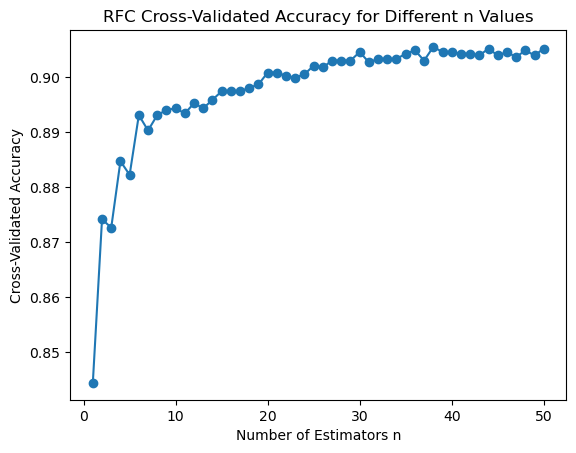

In [14]:
k_values = range(1, 51)
cv_scores = []

for k in k_values:
    rfc = RandomForestClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(rfc, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Estimators n')
plt.ylabel('Cross-Validated Accuracy')
plt.title('RFC Cross-Validated Accuracy for Different n Values')
plt.show()

The optimal max depth is 6 with an average training accuracy of 0.9068


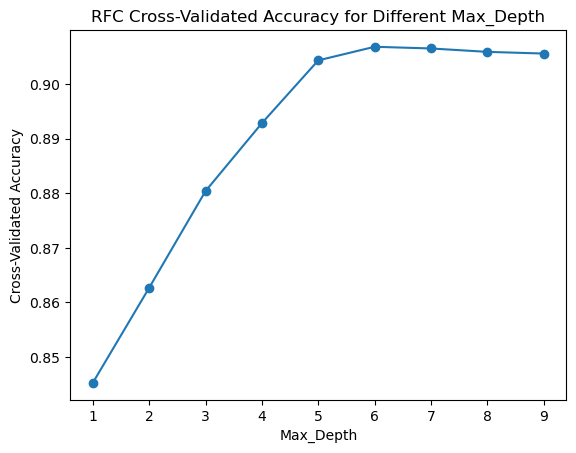

In [15]:
k_values = range(1, 10)
cv_scores = []

for k in k_values:
    rfc = RandomForestClassifier(n_estimators=38,max_depth=k,random_state=101)
    scores = cross_val_score(rfc, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal max depth is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Max_Depth')
plt.ylabel('Cross-Validated Accuracy')
plt.title('RFC Cross-Validated Accuracy for Different Max_Depth')
plt.show()

# Optimizing Parameters for Gradient Boost
The Gradient Boosting Classifier has several parameters that we can fine-tune. We start by optimizing its *n* parameter, then adjust the other common parameters using *RandomizedSearchCV()* to iterate through different combinations and output the combination with the best accuracy score. We could also use *GridSearchCV()* for a more thorough search, but to save on runtime, a randomized search will suffice.

**Note: Since the optimized *n* parameter is relatively high, we will test for overfitting at the end of the project.**

The optimal number of estimators is 70 with an average accuracy of 0.9077


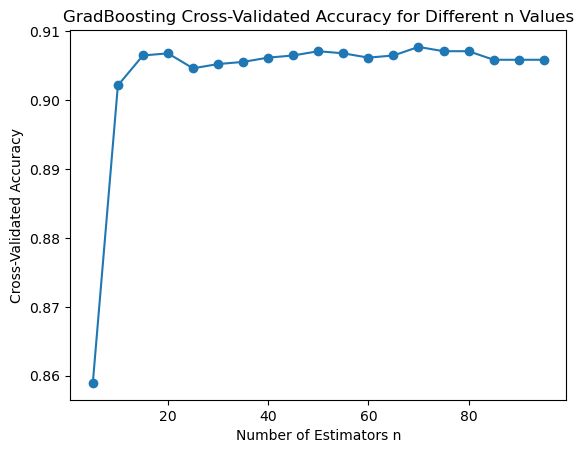

In [16]:
k_values = range(5,100,5)
cv_scores = []

for k in k_values:
    gd = GradientBoostingClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(gd, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Estimators n')
plt.ylabel('Cross-Validated Accuracy')
plt.title('GradBoosting Cross-Validated Accuracy for Different n Values')
plt.show()

In [17]:
# Chosen parameter distribution for Gradient Boosting
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1,0.15], 
    'max_depth': [3, 4, 5],            
    'subsample': [0.6,0.7,0.8, 0.9, 1.0]       
}

gb_clf = GradientBoostingClassifier(n_estimators=70,random_state=101)

random_search = RandomizedSearchCV(gb_clf, param_dist, n_iter=30, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Best Parameters: {'subsample': 0.8, 'max_depth': 3, 'learning_rate': 0.05}
Best Accuracy: 0.9083580460380786


# Optimizing XG Boost Parameters
XGBoost has many parameters that can improve accuracy. By using a random search, we can explore various combinations of these parameters to find an optimal set of values that maximizes accuracy.

In [32]:
param_dist = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.3, 0.5, 0.7, 0.9]
}

xgb = XGBClassifier(random_state=42)

# Randomized search with 10 iterations
random_search = RandomizedSearchCV(xgb, param_dist, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=101)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)


Best Parameters: {'subsample': 0.8, 'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best Accuracy: 0.907735321528425


# Optimizing SVC Parameters

In [27]:
param_dist = {
    'C': [0.1, 1, 10, 50],            
    'gamma': ['scale', 'auto', 0.1,0.2,0.3,0.4,0.5], 
    'kernel': ['rbf']                  
}

# Randomized search with 20 iterations
random_search = RandomizedSearchCV(SVC(random_state=42), param_dist,
                                   n_iter=20, cv=10, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)


Best Parameters: {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}
Best Accuracy: 0.8869207252181652


# Classification Tree Pruning
Classification trees, when not pruned, are prone to heavy overfitting on the training data. Pruning helps remove nodes likely created by noise in the training data. We also want to compare the accuracy of the pruned classification tree to the unpruned tree to assess any potential loss in accuracy due to pruning.

In [20]:
clf=DTC(criterion='entropy',random_state=101)
clf.fit(X_train,y_train)
accuracy_score(y_test,clf.predict(X_test))  #test accuracy with no pruning

0.8496894409937888

In [21]:
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)
kfold=skm.KFold(10,random_state=101,shuffle=True)
grid=skm.GridSearchCV(clf, {'ccp_alpha':ccp_path.ccp_alphas}, refit=True, cv=kfold, scoring='accuracy')
grid.fit(X_train,y_train)
grid.best_score_

0.9049408873667305

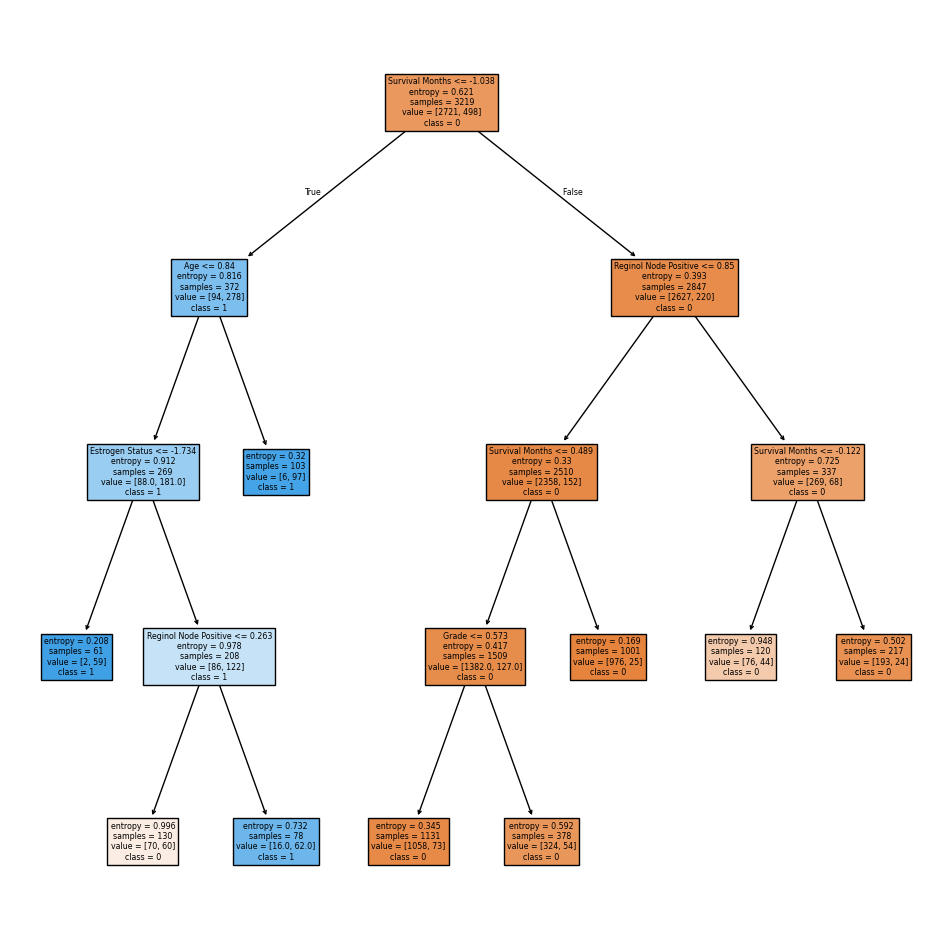

In [22]:
feature_names=list(X.columns)
fig, ax=subplots(figsize=(12,12))
best_=grid.best_estimator_
plot_tree(best_,feature_names=feature_names,class_names=['0','1'],filled=True,ax=ax)
plt.show()

In [23]:
accuracy_score(y_test,best_.predict(X_test)) #Test Accuracy for pruned tree

0.8993788819875776

# Evaluate Optimized Models
We can now evaluate our models with optimized parameters on the training data and rank them based on accuracy. Additionally, we include several other inferences to help us determine which model best fits the dataset overall.

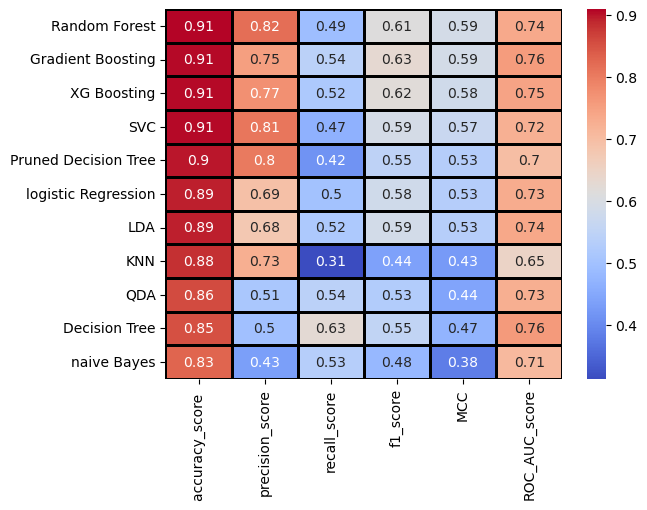

In [31]:
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

model_dic={
    'logistic Regression':LogisticRegression(),
    "Decision Tree":DTC(criterion='entropy'),
    'Pruned Decision Tree':best_,
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(n_estimators=38,max_depth=6),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=70,subsample=0.8,max_depth=3,learning_rate=0.05),
    'XG Boosting':XGBClassifier(n_estimators=250,subsample=0.8,max_depth=4,learning_rate=0.01,colsample_bytree=0.9),
    "KNN":KNeighborsClassifier(n_neighbors=9),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='rbf',gamma=0.1,C=1,probability=True),
}

acc_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),
                "MCC" :matthews_corrcoef(y_test,y_pred),
                "ROC_AUC_score" :roc_auc_score(y_test,y_pred)}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

# ROC Curves
We now evaluate the ROC curves for the five best-performing models based on our previous analyses.

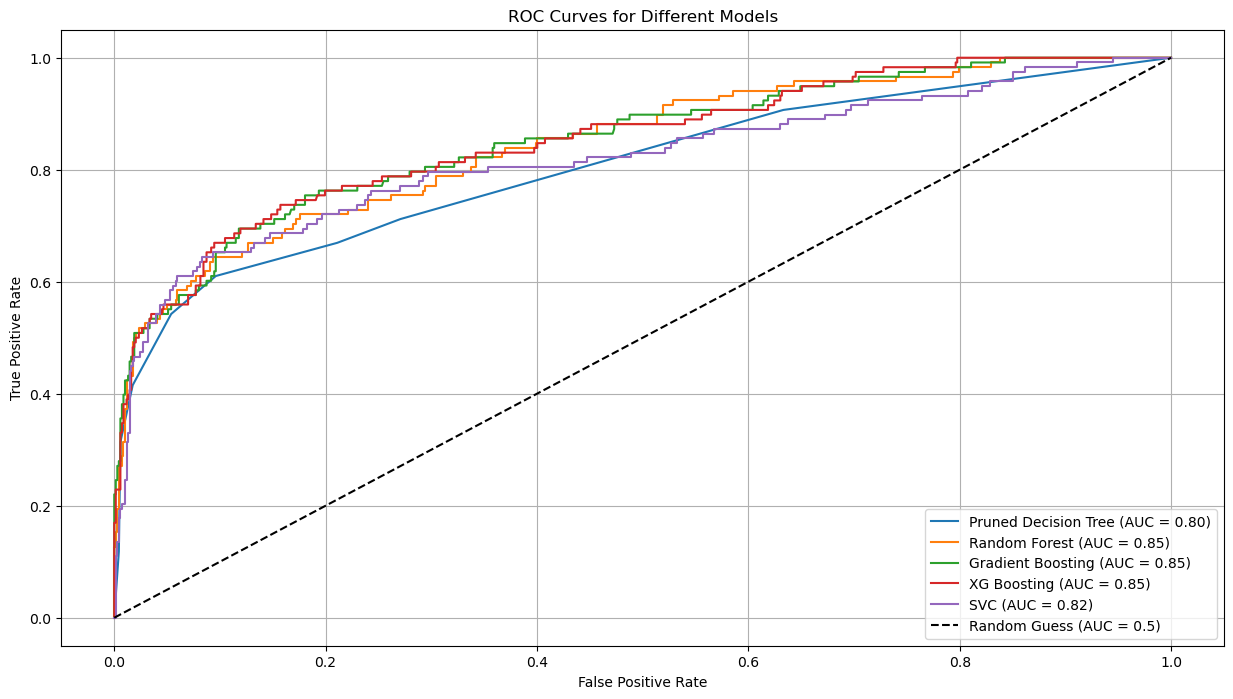

In [34]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(15, 8))

model_dic={
    'Pruned Decision Tree':best_,
    'Random Forest':RandomForestClassifier(n_estimators=38,max_depth=6),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=70,subsample=0.8,max_depth=3,learning_rate=0.05),
    'XG Boosting':XGBClassifier(n_estimators=250,subsample=0.8,max_depth=4,learning_rate=0.01,colsample_bytree=0.9),
    "SVC":SVC(kernel='rbf',gamma=0.1,C=1,probability=True)
}
for (i, model) in model_dic.items():
    model.fit(X_train,y_train)

    y_score=model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Test Top Models for Overfitting
Although we selected the top-performing models for our dataset, it’s essential to test them for overfitting. We do this by plotting the learning curves, which show the relationship between training size and model performance on both the training and cross-validation (CV) data.

When analyzing the learning curves, we’re looking for models where the training and CV scores converge as more training data is added. If the two scores are close and stable (i.e., there is minimal gap between them), it indicates that the model is likely well-generalized and not overfitting.

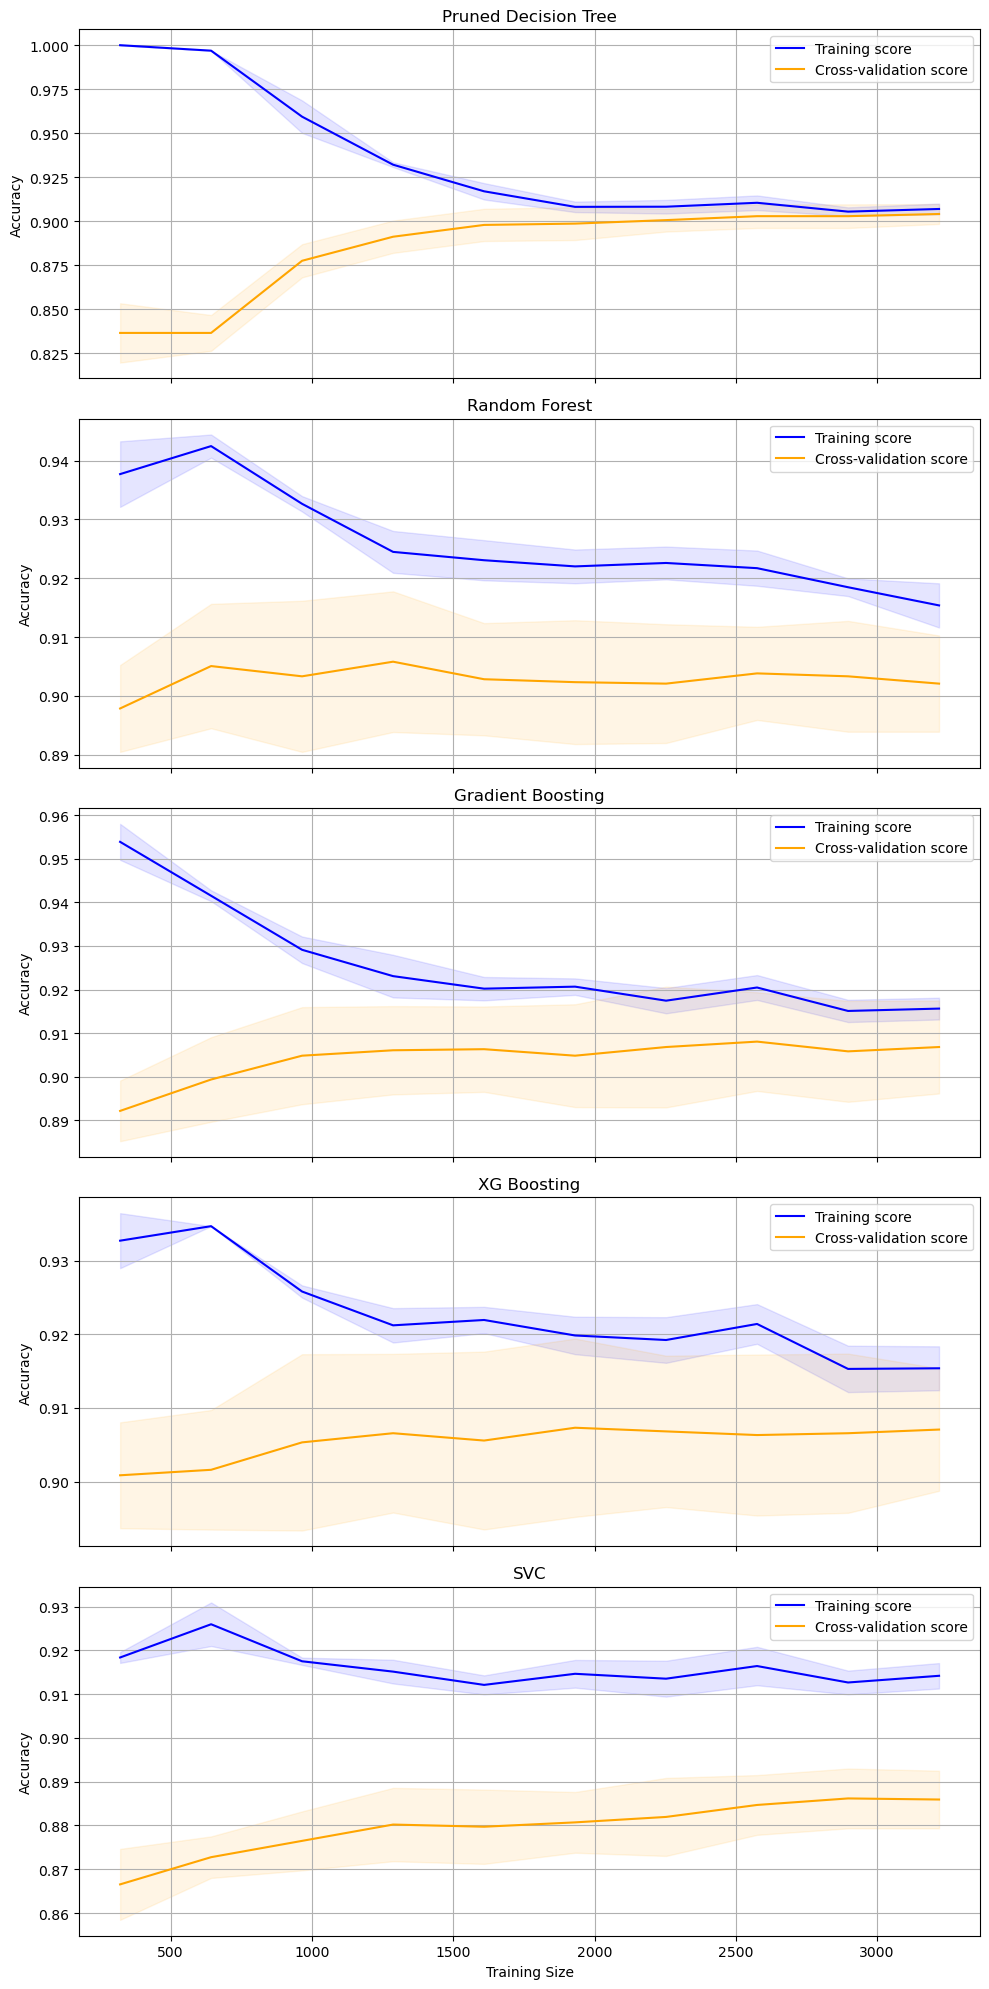

In [35]:
from sklearn.model_selection import learning_curve

model_dic={
    'Pruned Decision Tree':best_,
    'Random Forest':RandomForestClassifier(n_estimators=38,max_depth=6),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=70,subsample=0.8,max_depth=3,learning_rate=0.05),
    'XG Boosting':XGBClassifier(n_estimators=250,subsample=0.8,max_depth=4,learning_rate=0.01,colsample_bytree=0.9),
    "SVC":SVC(kernel='rbf',gamma=0.1,C=1,probability=True)
}

num_models = len(model_dic)
fig, axes = plt.subplots(num_models, 1, figsize=(10, num_models * 4), sharex=True)

for ax, (model_name, model_func) in zip(axes, model_dic.items()):
    model = model_func
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    # Mean and sd for the training and test scores
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve
    ax.plot(train_sizes, train_mean, label='Training score', color='blue')
    ax.plot(train_sizes, test_mean, label='Cross-validation score', color='orange')


    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.1, color='blue')
    ax.fill_between(train_sizes,
                    test_mean - test_std,
                    test_mean + test_std,
                    alpha=0.1, color='orange')

    # Subplots
    ax.set_title(model_name)
    ax.set_ylabel('Accuracy')
    ax.grid()
    ax.legend(loc='best')

plt.xlabel('Training Size')
plt.tight_layout()  # Adjust to prevent overlap
plt.show()